In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("employee_attrition.csv")

In [3]:
df.head()

,EmployeeID,Name,Age,Gender,Department,JobRole,MonthlySalary,ExperienceYears,JobSatisfaction,WorkLifeBalance,Overtime,DistanceFromHome,MaritalStatus,TrainingHours,Attrition
0,1,Melanie Robbins,NaN,Male,IT,Analyst,143924.0,4.0,5.0,2.0,No,48.0,Married,62.0,No
1,2,Anthony Vega,45.0,Male,HR,Manager,112496.0,33.0,5.0,4.0,Yes,43.0,Single,83.0,No
2,3,Larry Smith,47.0,Male,IT,Analyst,93745.0,18.0,1.0,1.0,No,2.0,Single,48.0,No
3,4,Vanessa Dunlap,57.0,Female,IT,Executive,52147.0,24.0,5.0,5.0,Yes,34.0,Single,41.0,No
4,5,Larry Perez,50.0,Female,Sales,Executive,130325.0,33.0,3.0,1.0,No,48.0,Married,7.0,Yes


In [4]:
df.shape

(500, 15)

In [5]:
df.columns

Index(['EmployeeID', 'Name', 'Age', 'Gender', 'Department', 'JobRole',
       'MonthlySalary', 'ExperienceYears', 'JobSatisfaction',
       'WorkLifeBalance', 'Overtime', 'DistanceFromHome', 'MaritalStatus',
       'TrainingHours', 'Attrition'],
      dtype='str')

In [6]:
df.dtypes

EmployeeID            int64
Name                    str
Age                 float64
Gender                  str
Department              str
JobRole                 str
MonthlySalary       float64
ExperienceYears     float64
JobSatisfaction     float64
WorkLifeBalance     float64
Overtime                str
DistanceFromHome    float64
MaritalStatus           str
TrainingHours       float64
Attrition               str
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        500 non-null    int64  
 1   Name              500 non-null    str    
 2   Age               468 non-null    float64
 3   Gender            482 non-null    str    
 4   Department        494 non-null    str    
 5   JobRole           489 non-null    str    
 6   MonthlySalary     475 non-null    float64
 7   ExperienceYears   471 non-null    float64
 8   JobSatisfaction   483 non-null    float64
 9   WorkLifeBalance   477 non-null    float64
 10  Overtime          482 non-null    str    
 11  DistanceFromHome  480 non-null    float64
 12  MaritalStatus     482 non-null    str    
 13  TrainingHours     480 non-null    float64
 14  Attrition         483 non-null    str    
dtypes: float64(7), int64(1), str(7)
memory usage: 58.7 KB


In [10]:
df.isnull()

,EmployeeID,Name,Age,Gender,Department,JobRole,MonthlySalary,ExperienceYears,JobSatisfaction,WorkLifeBalance,Overtime,DistanceFromHome,MaritalStatus,TrainingHours,Attrition
0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
496,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
497,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


In [11]:
df.isnull().sum()

EmployeeID           0
Name                 0
Age                 32
Gender              18
Department           6
JobRole             11
MonthlySalary       25
ExperienceYears     29
JobSatisfaction     17
WorkLifeBalance     23
Overtime            18
DistanceFromHome    20
MaritalStatus       18
TrainingHours       20
Attrition           17
dtype: int64

In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())

EmployeeID          0
Name                0
Age                 0
Gender              0
Department          0
JobRole             0
MonthlySalary       0
ExperienceYears     0
JobSatisfaction     0
WorkLifeBalance     0
Overtime            0
DistanceFromHome    0
MaritalStatus       0
TrainingHours       0
Attrition           0
dtype: int64


In [16]:
df.replace({'Attrition': {'Yes':1, 'No':0}}, inplace=True)

,EmployeeID,Name,Age,Gender,Department,JobRole,MonthlySalary,ExperienceYears,JobSatisfaction,WorkLifeBalance,Overtime,DistanceFromHome,MaritalStatus,TrainingHours,Attrition
0,1,Melanie Robbins,0.0,Male,IT,Analyst,143924.000000,4.0,5.000000,2.000000,No,48.0,Married,62.0,0
1,2,Anthony Vega,45.0,Male,HR,Manager,112496.000000,33.0,5.000000,4.000000,Yes,43.0,Single,83.0,0
2,3,Larry Smith,47.0,Male,IT,Analyst,93745.000000,18.0,1.000000,1.000000,No,2.0,Single,48.0,0
3,4,Vanessa Dunlap,57.0,Female,IT,Executive,52147.000000,24.0,5.000000,5.000000,Yes,34.0,Single,41.0,0
4,5,Larry Perez,50.0,Female,Sales,Executive,130325.000000,33.0,3.000000,1.000000,No,48.0,Married,7.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Mariah Kline,42.0,Female,Sales,Analyst,131704.000000,21.0,2.000000,5.000000,No,27.0,Single,71.0,1
496,497,Jason White,55.0,Male,HR,Analyst,37603.000000,15.0,3.000000,4.000000,Yes,23.0,Married,2.0,1
497,498,Connor Freeman,49.0,Male,Sales,Executive,136707.000000,32.0,3.000000,5.000000,Yes,45.0,Married,44.0,1
498,499,Kristy Robbins,29.0,Male,IT,Executive,143577.000000,18.0,1.000000,2.995807,No,29.0,Single,23.0,0


In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(500, 15)

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['EmployeeID', 'Age', 'MonthlySalary', 'ExperienceYears',
       'JobSatisfaction', 'WorkLifeBalance', 'DistanceFromHome',
       'TrainingHours'],
      dtype='str')

In [22]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
categorical_cols

Index(['Name', 'Gender', 'Department', 'JobRole', 'Overtime', 'MaritalStatus',
       'Attrition'],
      dtype='str')

In [23]:
df.describe()

,EmployeeID,Age,MonthlySalary,ExperienceYears,JobSatisfaction,WorkLifeBalance,DistanceFromHome,TrainingHours
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,38.342000,84819.052632,17.29087,3.014493,2.995807,25.637500,50.710417
std,144.481833,15.019327,35689.236118,9.97001,1.417680,1.421275,14.389439,27.722456
min,1.000000,0.000000,25061.000000,0.00000,1.000000,1.000000,1.000000,0.000000
25%,125.750000,29.000000,55186.000000,9.00000,2.000000,2.000000,13.000000,28.000000
50%,250.500000,39.500000,84819.052632,17.29087,3.000000,3.000000,25.637500,50.710417
75%,375.250000,50.000000,114189.750000,25.00000,4.000000,4.000000,38.000000,71.000000
max,500.000000,60.000000,149787.000000,35.00000,5.000000,5.000000,50.000000,100.000000


In [24]:
df['Attrition'].value_counts()

Attrition
1    267
0    233
Name: count, dtype: int64

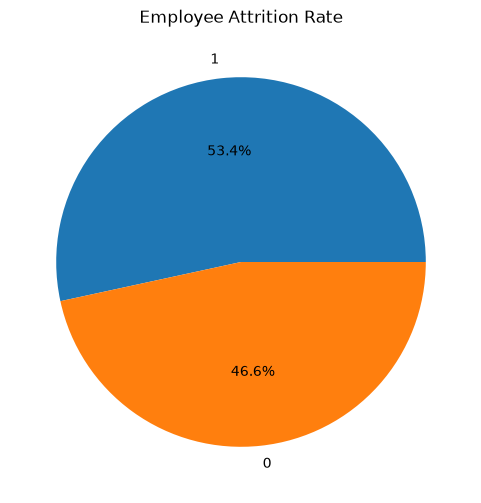

In [25]:
df['Attrition'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Employee Attrition Rate")
plt.ylabel("")
plt.show()

Employees working overtime show higher attrition.

Department-wise Attrition Analysis

In [26]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

print(department_attrition)

Attrition    0   1
Department        
Finance     65  75
HR          56  53
IT          70  58
Sales       42  81


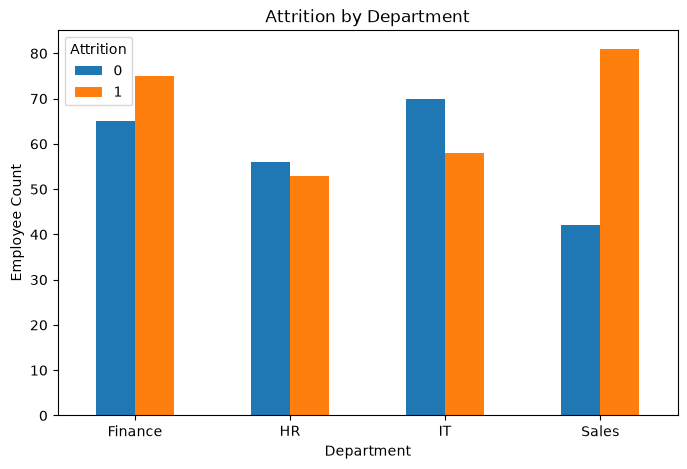

In [27]:
department_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.xticks(rotation=0)

plt.show()

Employees working overtime show higher attrition.

Salary-wise Attrition Analysis

In [80]:
bins = [0, 50000, 100000, 150000]

labels = ['Low', 'Medium', 'High']

df['SalaryGroup'] = pd.cut(
    df['MonthlySalary'],
    bins=bins,
    labels=labels
)

In [81]:
df[['MonthlySalary', 'SalaryGroup']].head()

,MonthlySalary,SalaryGroup
0,143924.0,High
1,112496.0,High
2,93745.0,Medium
3,52147.0,Medium
4,130325.0,High


In [82]:
salary_attrition = df.groupby('SalaryGroup')['Attrition'].mean() * 100

print(salary_attrition)

SalaryGroup
Low       48.979592
Medium    54.450262
High           50.0
Name: Attrition, dtype: object


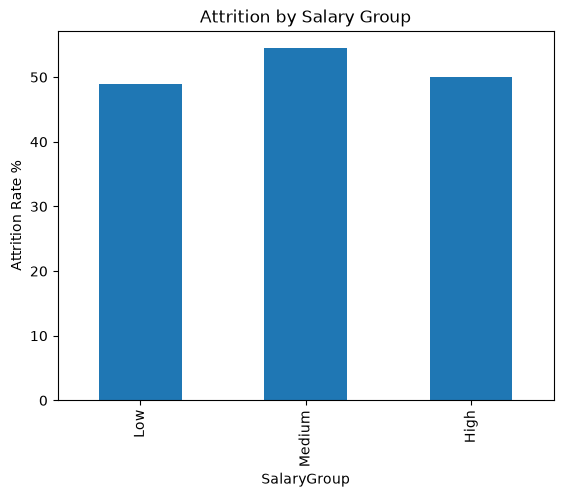

In [83]:
salary_attrition.plot(kind='bar')

plt.title("Attrition by Salary Group")

plt.ylabel("Attrition Rate %")

plt.show()

Employees working overtime show higher attrition.

In [36]:
experience_attrition = pd.crosstab(
    df['ExperienceYears'],
    df['Attrition']
)
print(experience_attrition)

Attrition         0   1
ExperienceYears        
0.00000          11  10
1.00000           8   5
2.00000           3   6
3.00000           9   8
4.00000           9   4
5.00000           7   6
6.00000           5   4
7.00000           7   6
8.00000           6   7
9.00000           4   2
10.00000          5   7
11.00000          6   5
12.00000          6   4
13.00000          5   4
14.00000          3  10
15.00000         10  11
16.00000          6  13
17.00000          8   6
17.29087         10  19
18.00000          6  10
19.00000          7   7
20.00000          8  10
21.00000          5   5
22.00000          5   4
23.00000          7   8
24.00000          7   9
25.00000          9   5
26.00000          3   8
27.00000          5   7
28.00000          6   7
29.00000          8   9
30.00000          7   5
31.00000          5  10
32.00000          4   8
33.00000          6   7
34.00000          5   6
35.00000          2   5


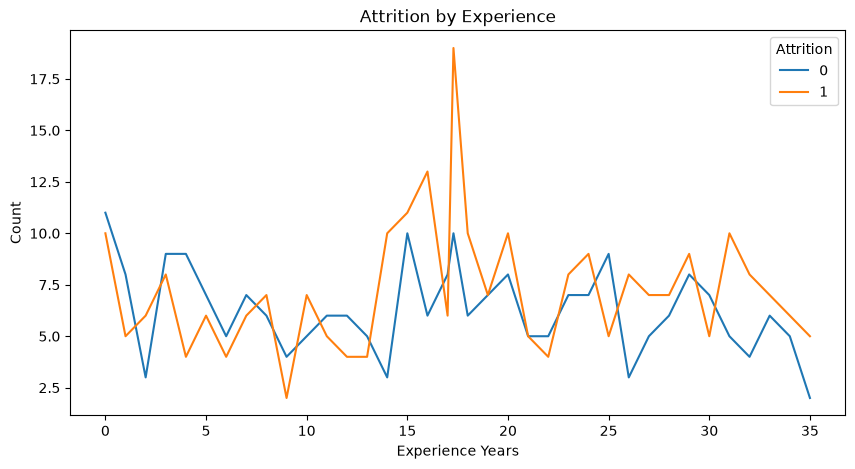

In [40]:
experience_attrition.plot(
    figsize=(10,5)
)

plt.title("Attrition by Experience")
plt.xlabel("Experience Years")
plt.ylabel("Count")

plt.show()

Employees working overtime show higher attrition.

In [42]:
overtime_attrition = pd.crosstab(
    df['Overtime'],
    df['Attrition']
)

print(overtime_attrition)

Attrition    0    1
Overtime           
No         125  139
Yes        108  128


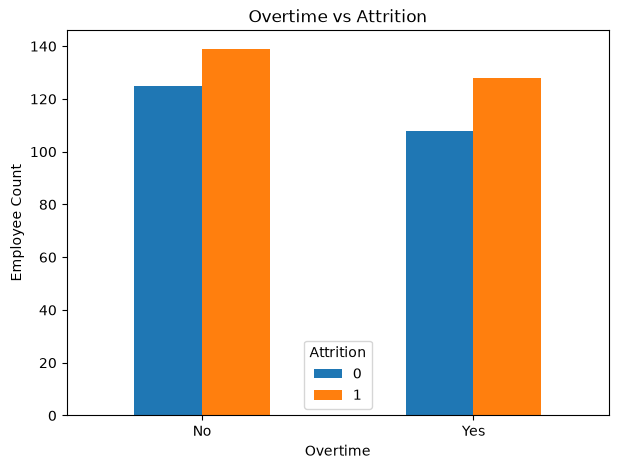

In [43]:
overtime_attrition.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Overtime vs Attrition")
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.xticks(rotation=0)

plt.show()

Employees working overtime show higher attrition.

In [44]:
job_attrition = pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition']
)

print(job_attrition)

Attrition         0   1
JobSatisfaction        
1.000000         44  58
2.000000         40  46
3.000000         48  56
3.014493          7  10
4.000000         39  46
5.000000         55  51


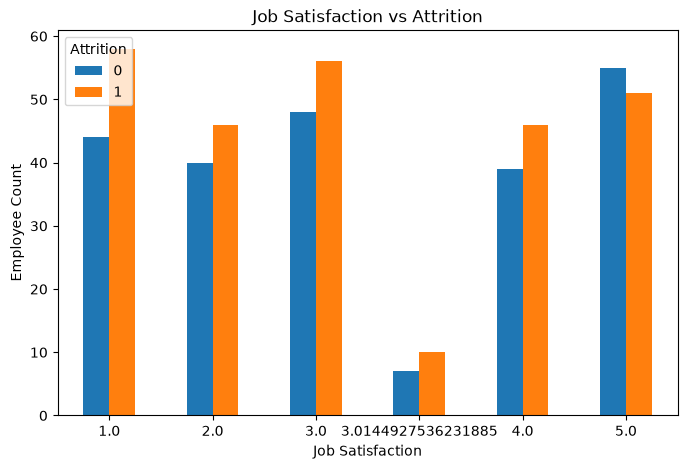

In [45]:
job_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Employee Count")

plt.xticks(rotation=0)

plt.show()

Employees working overtime show higher attrition.

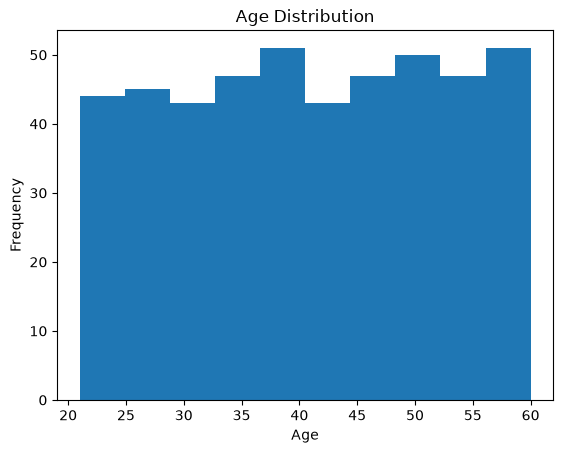

In [4]:
plt.hist(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Employees working overtime show higher attrition.

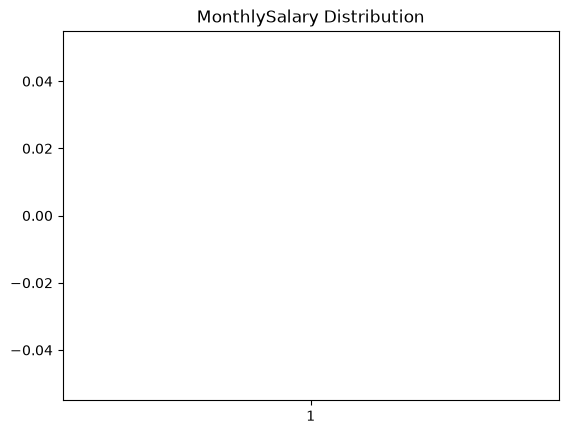

In [6]:
plt.boxplot(df['MonthlySalary'])

plt.title("MonthlySalary Distribution")

plt.show()

Employees working overtime show higher attrition.

In [25]:
wlb_attrition = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition']
)
print(wlb_attrition)

Attrition        No  Yes
WorkLifeBalance         
1.0              50   48
2.0              42   52
3.0              34   45
4.0              46   49
5.0              44   51


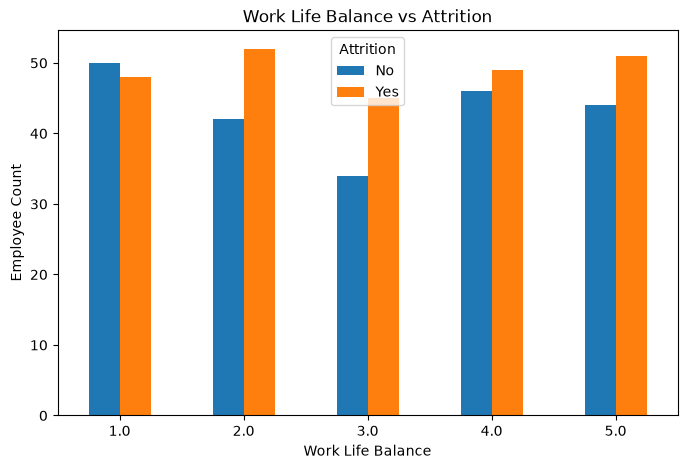

In [26]:
wlb_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Work Life Balance vs Attrition")
plt.xlabel("Work Life Balance")
plt.ylabel("Employee Count")

plt.xticks(rotation=0)

plt.show()

Employees working overtime show higher attrition.

In [22]:
bins = [18, 25, 35, 45, 60]

labels = ['18-25', '26-35', '36-45', '46-60']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)
age_attrition = pd.crosstab(
    df['AgeGroup'],
    df['Attrition']
)
print(age_attrition)

Attrition  No  Yes
AgeGroup          
18-25      19   29
26-35      52   57
36-45      65   56
46-60      81   94


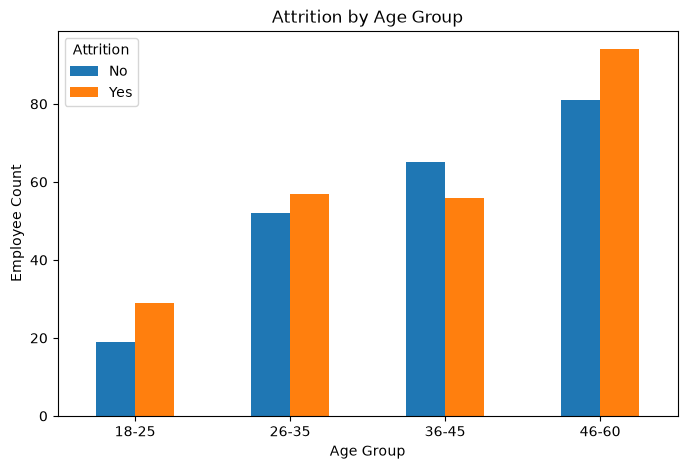

In [23]:
age_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Employee Count")

plt.xticks(rotation=0)

plt.show()

Employees working overtime show higher attrition.

In [36]:
income_attrition = df.groupby(
    'Attrition'
)['MonthlySalary'].mean()
print(income_attrition)

Attrition
No     84845.463964
Yes    84204.983122
Name: MonthlySalary, dtype: float64


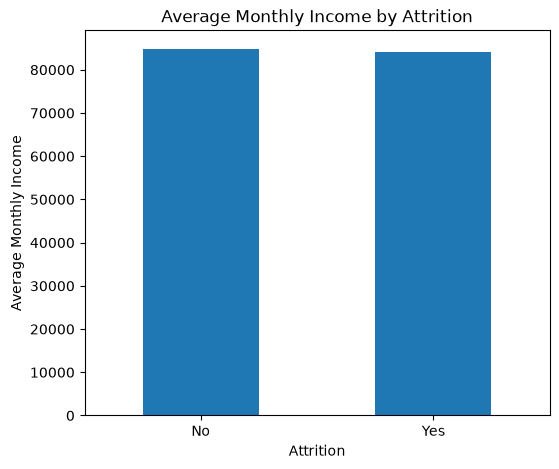

In [37]:
income_attrition.plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Average Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Monthly Income")

plt.xticks(rotation=0)

plt.show()

Employees working overtime show higher attrition.

In [7]:
df.groupby('Department')['MonthlySalary'].mean()

Department
Finance    85382.358779
HR         82623.715686
IT         84471.613445
Sales      86709.296610
Name: MonthlySalary, dtype: float64

In [11]:
df.groupby('Attrition')['ExperienceYears'].mean()

Attrition
No     16.439462
Yes    17.943966
Name: ExperienceYears, dtype: float64

In [12]:
df.groupby('Gender')['Attrition'].value_counts()

Gender  Attrition
Female  Yes          116
        No           112
Male    Yes          125
        No           113
Name: count, dtype: int64

In [39]:
df.nunique()

EmployeeID          500
Name                499
Age                  40
Gender                2
Department            4
JobRole               3
MonthlySalary       475
ExperienceYears      36
JobSatisfaction       5
WorkLifeBalance       5
Overtime              2
DistanceFromHome     50
MaritalStatus         2
TrainingHours       100
Attrition             2
AgeGroup              4
dtype: int64

In [40]:
df.corr(numeric_only=True)

,EmployeeID,Age,MonthlySalary,ExperienceYears,JobSatisfaction,WorkLifeBalance,DistanceFromHome,TrainingHours
EmployeeID,1.000000,-0.038041,-0.018708,-0.004434,0.033511,-0.008821,-0.021234,0.055666
Age,-0.038041,1.000000,-0.023078,0.009579,0.047770,0.035996,0.064290,-0.052057
MonthlySalary,-0.018708,-0.023078,1.000000,-0.032754,0.058219,0.015585,0.025246,0.024509
ExperienceYears,-0.004434,0.009579,-0.032754,1.000000,-0.079363,0.020941,-0.007948,-0.009552
JobSatisfaction,0.033511,0.047770,0.058219,-0.079363,1.000000,-0.039143,0.027169,-0.015894
WorkLifeBalance,-0.008821,0.035996,0.015585,0.020941,-0.039143,1.000000,0.101932,-0.005390
DistanceFromHome,-0.021234,0.064290,0.025246,-0.007948,0.027169,0.101932,1.000000,0.013833
TrainingHours,0.055666,-0.052057,0.024509,-0.009552,-0.015894,-0.005390,0.013833,1.000000


In [41]:
df.sort_values(
    by='MonthlySalary',
    ascending=False
)

,EmployeeID,Name,Age,Gender,Department,JobRole,MonthlySalary,ExperienceYears,JobSatisfaction,WorkLifeBalance,Overtime,DistanceFromHome,MaritalStatus,TrainingHours,Attrition,AgeGroup
482,483,Jessica Russo,51.0,Female,HR,Executive,149787.0,4.0,1.0,NaN,Yes,NaN,Married,71.0,No,46-60
173,174,Deborah Brooks,59.0,Female,Finance,Manager,149373.0,15.0,4.0,1.0,Yes,2.0,Single,15.0,Yes,46-60
442,443,Henry Gray,53.0,Female,Sales,Manager,149293.0,3.0,4.0,1.0,No,48.0,Single,84.0,No,46-60
375,376,James Harris,60.0,Male,IT,Analyst,148549.0,9.0,1.0,5.0,No,22.0,Married,93.0,Yes,46-60
102,103,Katie Rodriguez,45.0,Female,IT,Executive,148511.0,35.0,5.0,4.0,No,25.0,Single,100.0,Yes,36-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,382,Patrick Powell,27.0,Male,Sales,Analyst,NaN,8.0,4.0,4.0,No,39.0,Single,78.0,Yes,26-35
424,425,Thomas Walsh,NaN,Male,IT,Executive,NaN,9.0,4.0,2.0,Yes,41.0,Single,NaN,No,NaN
438,439,Catherine Carter,41.0,Male,HR,Executive,NaN,7.0,1.0,5.0,No,38.0,Single,44.0,No,36-45
480,481,Cheryl Martinez,58.0,Male,IT,Analyst,NaN,33.0,1.0,1.0,NaN,5.0,Married,79.0,No,46-60


In [42]:
df['Department'].value_counts()

Department
Finance    134
IT         128
Sales      123
HR         109
Name: count, dtype: int64

Key Findings:
1. Employees working overtime show higher attrition.

2. Lower salary groups have higher employee turnover.

3. Employees with low job satisfaction are more likely to leave.

4. Poor work-life balance contributes to attrition.

5. Certain departments experience higher attrition rates.

Recommendations:

1. Reduce excessive overtime.

2. Improve employee engagement initiatives.

3. Provide better salary benefits and incentives.

4. Improve work-life balance policies.

5. Focus on employee satisfaction programs.

Conclusion:
This project analyzed employee attrition using data analysis and visualization techniques.
The analysis identified salary, overtime, work-life balance, and job satisfaction as major factors affecting employee turnover.

Thank You